In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.ticker import MultipleLocator, FixedLocator
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from utils import load_VAE_data, compute_features, compute_features_v2
from figs_utils import plot_detection_results, load_v_data

In [2]:
def plot_features(data, min_index, max_index, features, title):
    data = data.iloc[min_index:max_index]
    plt.figure(figsize=(6, 3))
    for feature in features:
        plt.scatter(data.index, data[feature], s=1, alpha=0.7, label=feature)
    plt.title(title)
    plt.xlabel('Index', fontsize='0.1')
    plt.ylabel('Value')
    plt.legend(fontsize='10', markerscale=3) # markerscale=0, handletextpad=0, labelspacing=0.1
    plt.show()

In [3]:
window = 100
features = ['VRTG', 'VRTG_diff_1', 'VRTG_diff_10', 'VRTG_z']

# data
train_data, val_data, test_data = load_VAE_data('data')

train_flight_ids = train_data['flight_id'].values
val_flight_ids = val_data['flight_id'].values
test_flight_ids = test_data['flight_id'].values

train_data = compute_features_v2(train_data, rolling_window_size=window)
val_data = compute_features_v2(val_data, rolling_window_size=window)
test_data = compute_features_v2(test_data, rolling_window_size=window)

X_train, y_train = train_data[features].values, (train_data['status'] == 'abnormal').astype(int).values
X_val, y_val = val_data[features].values, (val_data['status'] == 'abnormal').astype(int).values
X_test, y_test = test_data[features].values, (test_data['status'] == 'abnormal').astype(int).values

train_flight_ids:  [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57] length:  18
val_flight_ids: [98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112] length:  15
test_flight_ids: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 31, 33, 34, 35, 36, 37, 38, 39, 58, 59, 60, 61, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 93, 94, 95, 96, 97, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133] length:  86
Train size: 1539601, Val size: 1337017, Test size: 7079038


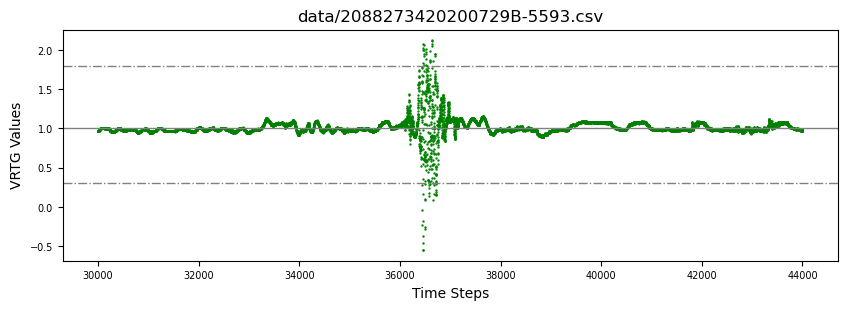

In [6]:
red_data_path = "data/2088273420200729B-5593.csv"
plot_detection_results(red_data_path, 30000, 44000)

In [ ]:
red_data_path = "data/4321007820250201122353-737.csv"   
plot_detection_results(red_data_path, 60000, 90000)

In [115]:
# target_data = train_data[train_data['flight_id'] == 41]
target_data = test_data[test_data['flight_id'] == 9]
# target_data = val_data[val_data['flight_id'] == 10]
target_data.index = range(len(target_data))
target_data

,VRTG,status,flight_id,index,VRTG_diff_1,VRTG_diff_10,VRTG_z
0,0.995,normal,9,0,0.000,0.995,0.000000
1,0.995,normal,9,1,0.000,0.995,0.000000
2,0.995,normal,9,2,0.000,0.995,0.000000
3,0.993,normal,9,3,-0.002,0.993,-1.498501
4,0.995,normal,9,4,0.002,0.995,0.446714
...,...,...,...,...,...,...,...
79163,5.320,abnormal,9,79163,8.127,0.009,0.994240
79164,-2.723,abnormal,9,79164,-8.043,0.077,-0.984405
79165,5.309,abnormal,9,79165,8.032,-0.013,0.991632
79166,-2.805,abnormal,9,79166,-8.114,-0.078,-1.004568


In [117]:
target_data.columns

Index(['VRTG', 'status', 'flight_id', 'index', 'VRTG_diff_1', 'VRTG_diff_10',
       'VRTG_z'],
      dtype='object')

In [ ]:
Index(['VRTG', 'status', 'flight_id', 'index', 'VRTG_diff_1', 'VRTG_diff_10',
       'VRTG_z'],
      dtype='object')

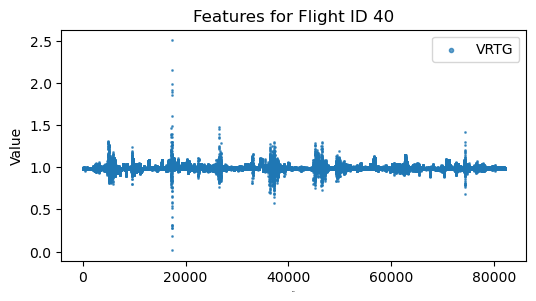

In [112]:
plot_features(target_data, 0, 100000, ['VRTG'], title='Features for Flight ID 40')


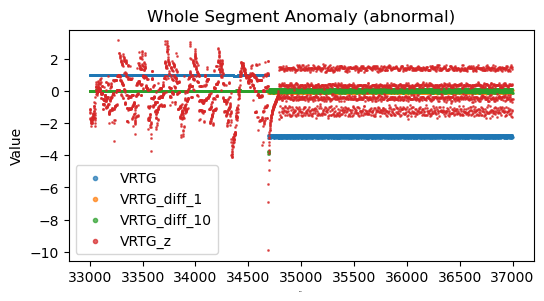

In [113]:
target_data = test_data[test_data['flight_id'] == 9]
plot_features(target_data, 33000, 37000, ['VRTG', 'VRTG_diff_1', 'VRTG_diff_10', 'VRTG_z'], title='Whole Segment Anomaly (abnormal)')

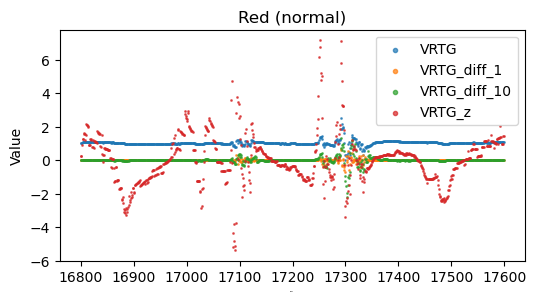

In [114]:
target_data = test_data[test_data['flight_id'] == 28]
target_data.index = range(len(target_data))
plot_features(target_data, 16800, 17600, ['VRTG', 'VRTG_diff_1', 'VRTG_diff_10', 'VRTG_z'], title='Red (normal)')

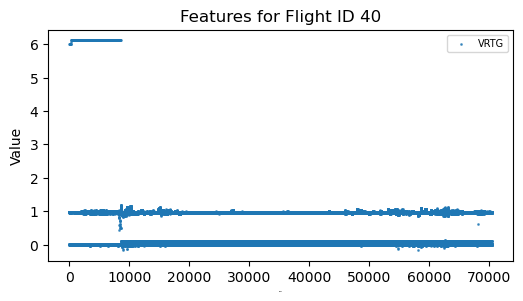

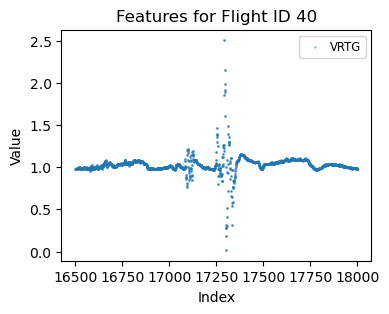

In [26]:
plot_features(target_data, 16500, 18000, ['VRTG'], title='Features for Flight ID 40')

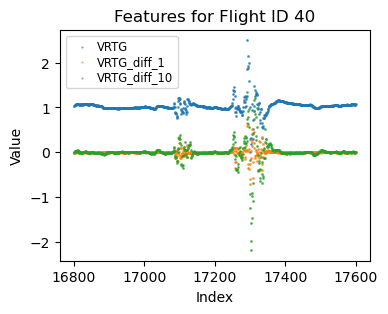

In [27]:
plot_features(target_data, 16800, 17600, ['VRTG', 'VRTG_diff_1', 'VRTG_diff_10'], title='Features for Flight ID 40')


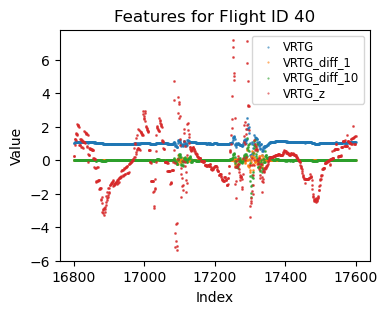

In [28]:
plot_features(target_data, 16800, 17600, ['VRTG', 'VRTG_diff_1', 'VRTG_diff_10', 'VRTG_z'], title='Features for Flight ID 40')


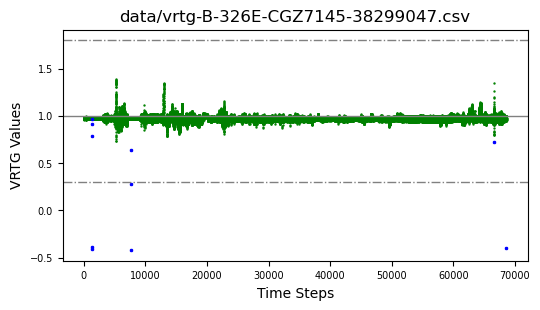

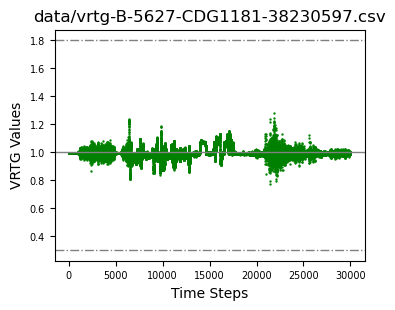

In [2]:
red_data_path = "data/vrtg-B-5627-CDG1181-38230597.csv"
plot_detection_results(red_data_path, 0, 30000)


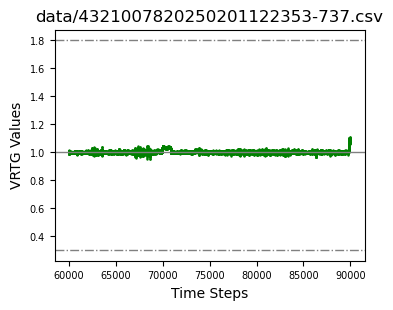

In [13]:
red_data_path = "data/4321007820250201122353-737.csv"
plot_detection_results(red_data_path,60000,90000)


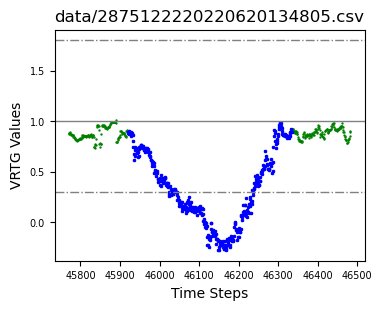

In [10]:
red_data_path = "data/2875122220220620134805.csv"
plot_detection_results(red_data_path, 45920-150, 46334+150)


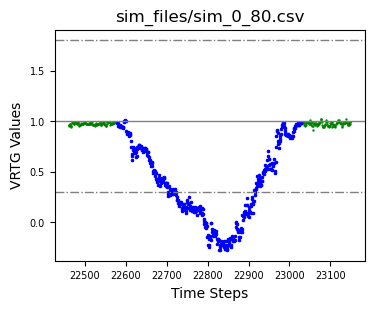

In [19]:
red_data_path = "sim_files/sim_0_80.csv"
plot_detection_results(red_data_path, 22560-100, 23050+100)


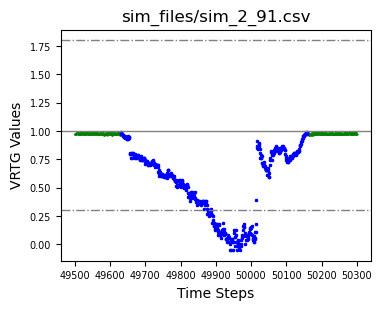

In [22]:
red_data_path = "sim_files/sim_2_91.csv"
plot_detection_results(red_data_path, 49600-100, 50200+100)


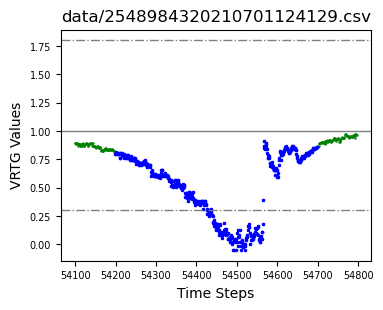

In [24]:
red_data_path = "data/2548984320210701124129.csv"
plot_detection_results(red_data_path, 54199-100, 54697+100)


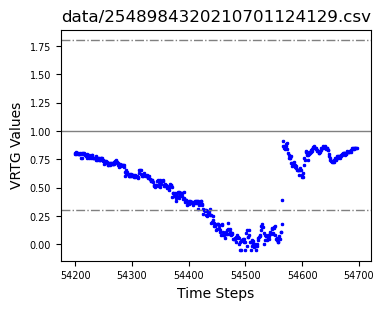

In [7]:
red_data_path = "data/2548984320210701124129.csv"
plot_detection_results(red_data_path, 54199, 54697)


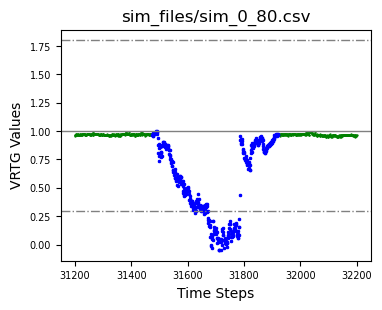

In [13]:
red_data_path = "sim_files/sim_0_80.csv"
plot_detection_results(red_data_path, 31200, 32200)


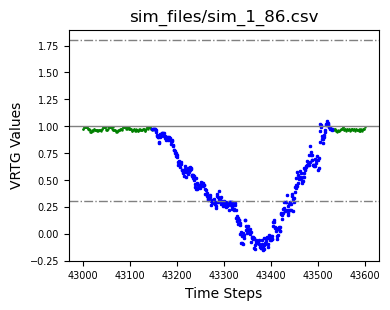

In [17]:
red_data_path = "sim_files/sim_1_86.csv"
plot_detection_results(red_data_path, 43000, 43600)


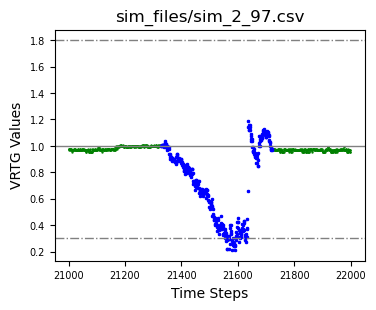

In [21]:
red_data_path = "sim_files/sim_2_97.csv"
plot_detection_results(red_data_path, 21000, 22000)


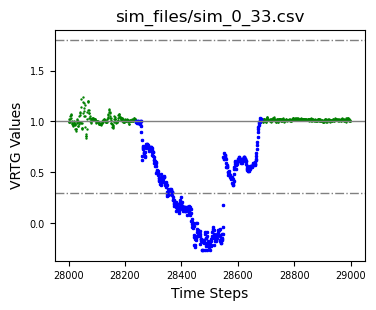

In [33]:
red_data_path = "sim_files/sim_0_33.csv"
plot_detection_results(red_data_path, 28000, 29000)


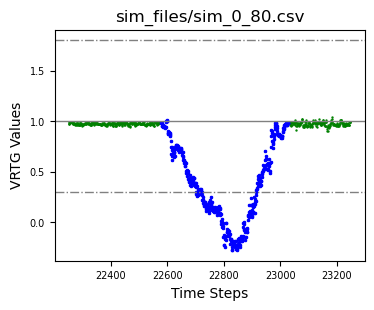

In [8]:
red_data_path = "sim_files/sim_0_80.csv"
plot_detection_results(red_data_path, 22250, 23250)


In [ ]:
import pickle
results_dict = pickle.load(open('results_dict.pkl', 'rb'))
results_dict.keys()

results_dict['sim_0']

df_metrics = pd.DataFrame({'predictions': results_dict['sim_0']['predictions'], 'labels': results_dict['sim_0']['labels']})
df_metrics

dict_keys([28, 33, 46, 50, 59, 70, 78, 86, 92, 95, 'sim_0', 'sim_1', 'sim_2', 'sim_3', 'sim_4', 'sim_5', 'sim_6', 'sim_7', 'sim_8', 'sim_9', 132, 133])

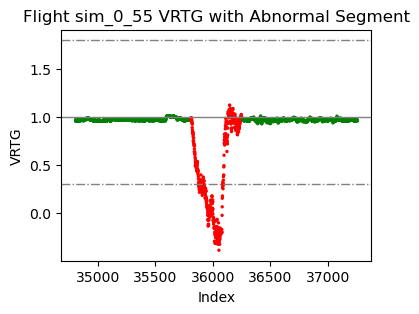

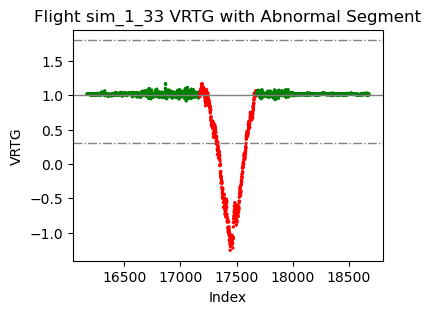

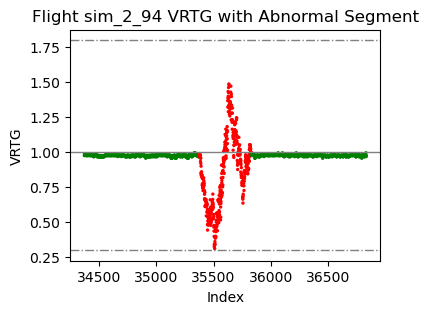

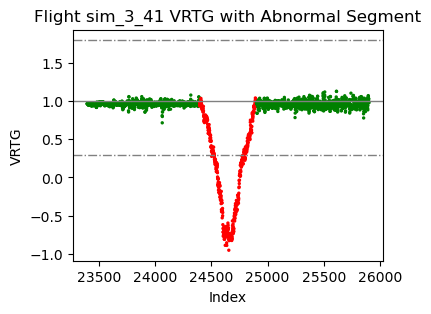

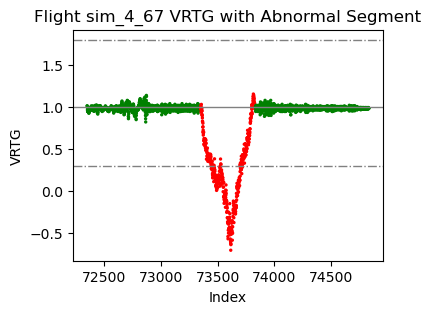

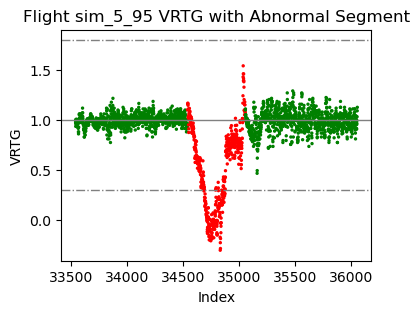

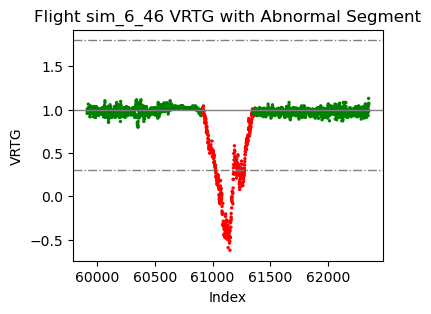

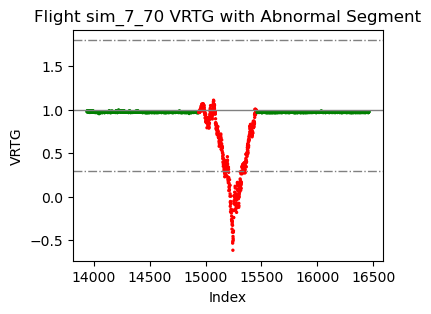

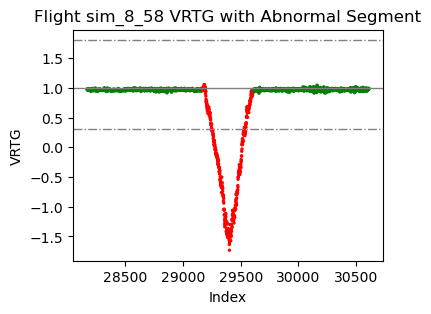

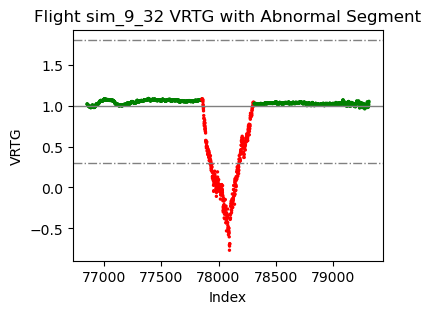

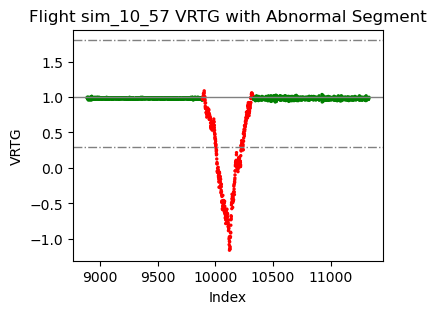

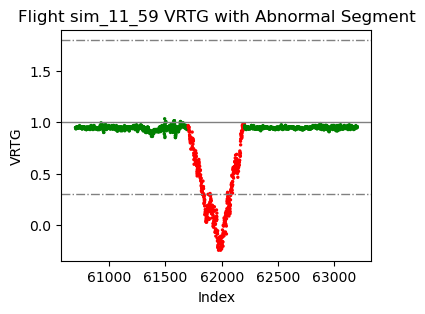

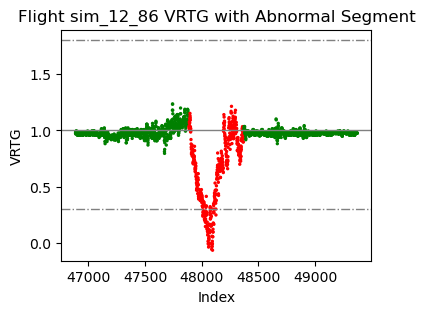

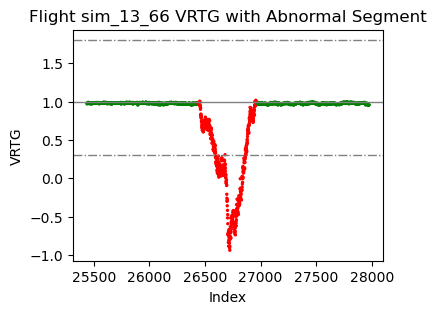

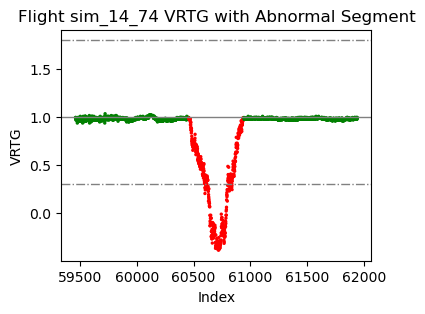

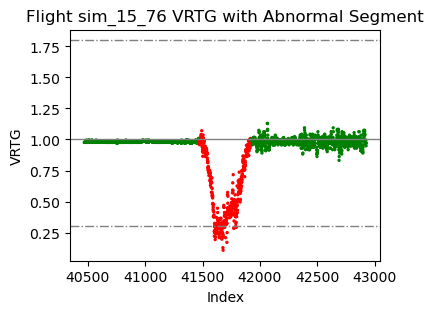

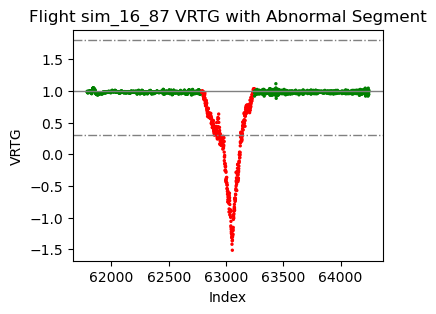

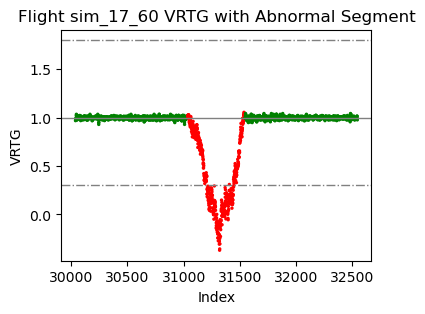

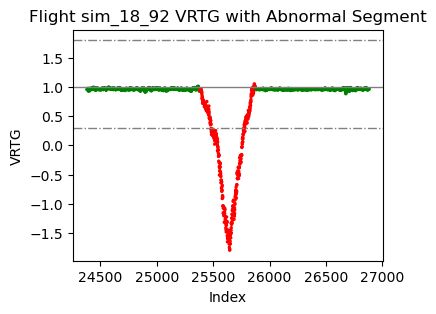

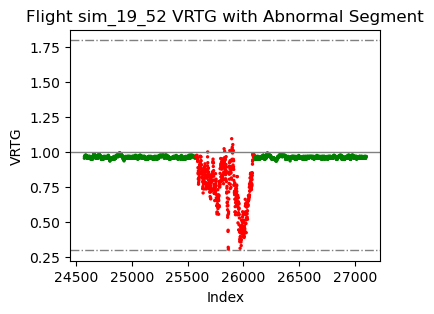

In [ ]:
sim_data = pd.read_csv('sim_data.csv')
for fid in sim_data['flight_id'].unique():
    df_flight = sim_data[sim_data['flight_id'] == fid]
    abnormal_indices = df_flight[df_flight['status'] == 'abnormal'].index
    if len(abnormal_indices) == 0:
        continue
    start = max(abnormal_indices[0] - 1000, 0)
    end = min(abnormal_indices[-1] + 1000, df_flight.index[-1])
    df_plot = df_flight.loc[start:end]
    plt.figure(figsize=(4, 3))
    plt.axhline(1.8, color='gray', linestyle='-.', linewidth=1)
    plt.axhline(1, color='gray', linestyle='-',  linewidth=1)
    plt.axhline(0.3, color='gray', linestyle='-.', linewidth=1)
    plt.scatter(df_plot['index'], df_plot['VRTG'], c=(df_plot['status'] == 'abnormal').map({True: 'red', False: 'green'}), s=2)
    plt.title(f"Flight {fid} VRTG with simul")
    plt.xlabel("Index")
    plt.ylabel("VRTG")
    plt.show()

In [66]:

def generate_parametric_v_segment(
    length=None,
    dip_range=(0.85, 1.2),
    left_slope_range=(-0.0048, -0.0025),
    right_slope_range=(0.004, 0.006),
    asymmetry_range=(0.53, 0.60),
    noise_level=0.03,
    seed=None,
    # --- 真实感增强（上一版已有的） ---
    curvature_strength=(0.18, 0.28),
    hetero_noise_alpha=(0.0, 1.5),
    hetero_noise_band=(0.10, 0.20),
    notch_prob=0.35,
    notch_amp_frac=(0.08, 0.28),
    notch_width_frac=(0.01, 0.04),
    plateau_prob=0.25,
    plateau_width_frac=(0.02, 0.06),
    plateau_jitter=0.05,
    jumps_lam=1.0,
    jump_amp_frac=(0.03, 0.12),
    jump_halfwidth=(0, 2),
    endpoint_jitter=0.03,
    # ---------- 新增：动量/小趋势 ----------
    momentum_prob=0.85,                 # 有多大概率给本段加“动量”
    momentum_rho_range=(0.85, 0.98),    # AR(1) 的相关系数 rho，越大惯性越强
    momentum_scale=(0.6, 1.6),          # 动量幅度 = 该系数 * noise_level
    momentum_pieces=(1, 3),             # 分段 AR(1) 的段数（>1 时每段重启方向，模拟趋势变化）
    momentum_detrend=True               # 加完动量后是否去线性漂移，保持端点可对齐
):
    rng = np.random.default_rng(seed)

    # 1) 随机长度 & 位置
    if length is None:
        length = int(rng.integers(440, 540))
    p = int(length * rng.uniform(*asymmetry_range))
    p = int(np.clip(p, 1, length - 1))

    dip = float(rng.uniform(*dip_range))

    # 2) 斜率
    m_left  = float(rng.uniform(abs(left_slope_range[1]), abs(left_slope_range[0])))
    m_right = float(rng.uniform(*right_slope_range))

    # 3) 线性骨架
    left_idx  = np.arange(p)
    right_idx = np.arange(length - p)
    left  = -dip + m_left  * ((p - 1) - left_idx)
    right = -dip + m_right * right_idx
    v = np.concatenate([left, right]).astype(float)

    # 4) 非线性弯曲
    curv_amp = rng.uniform(*curvature_strength) * dip
    if curv_amp > 0:
        denomL = max(p - 1, 1)
        tL = ((p - 1) - left_idx) / denomL
        denomR = max(length - p - 1, 1)
        tR = (right_idx) / denomR if denomR > 0 else np.zeros_like(right_idx, dtype=float)
        kL = curv_amp * rng.uniform(0.6, 1.4) * (1 if rng.random() < 0.5 else -1)
        kR = curv_amp * rng.uniform(0.6, 1.4) * (1 if rng.random() < 0.5 else -1)
        v[:p]  += kL * (tL**2)
        v[p:]  += kR * (tR**2)

    # ---------- 新增：给整段加“动量趋势” ----------
    if rng.random() < momentum_prob:
        rho = rng.uniform(*momentum_rho_range)
        scale = rng.uniform(*momentum_scale) * (noise_level if noise_level else 0.03)

        # 分段 AR(1)：每段独立初始化，模拟趋势换向
        n_pieces = int(rng.integers(momentum_pieces[0], momentum_pieces[1] + 1))
        # 切点均匀，但带随机扰动
        cuts = np.linspace(0, length, n_pieces + 1).astype(int)
        jitter = rng.integers(-max(1, length // (20*n_pieces)), max(1, length // (20*n_pieces))+1, size=n_pieces-1)
        for i in range(1, len(cuts)-1):
            cuts[i] = int(np.clip(cuts[i] + jitter[i-1], cuts[i-1]+1, cuts[i+1]-1))
        mom = np.zeros(length, dtype=float)
        pos = 0
        for i in range(n_pieces):
            L = cuts[i]; R = cuts[i+1]
            if R <= L: 
                continue
            seg_len = R - L
            e = np.zeros(seg_len, dtype=float)
            # 段首偏置，决定本段“走向”，可正可负
            e0 = rng.normal(0, scale * 0.5) * (1 if rng.random() < 0.5 else -1)
            e[0] = e0
            eps = rng.normal(0, scale, size=seg_len-1)
            for t in range(1, seg_len):
                e[t] = rho * e[t-1] + eps[t-1]
            mom[L:R] = e
            pos = R

        if momentum_detrend and length > 1:
            # 去除线性漂移，避免端点被整体抬高/压低
            slope = (mom[-1] - mom[0]) / (length - 1)
            trend = mom[0] + slope * np.arange(length)
            mom = mom - trend + mom.mean()

        v += mom
    # ---------- 动量结束 ----------

    # 5) 端点对齐（便于与背景平滑衔接）
    target_left  = rng.normal(0.0, endpoint_jitter)
    target_right = rng.normal(0.0, endpoint_jitter)
    corr = np.linspace(target_left - v[0], target_right - v[-1], length)
    v += corr

    # 6) 异方差噪声
    if noise_level and noise_level > 0:
        alpha = rng.uniform(*hetero_noise_alpha)
        band  = rng.uniform(*hetero_noise_band) * length
        center = p - 0.5
        dist = np.arange(length) - center
        weight = np.exp(-0.5 * (dist / (band + 1e-6))**2)
        sigma = noise_level * (1.0 + alpha * weight)
        v += rng.normal(0.0, sigma)
    else:
        alpha = 0.0

    # 7) 底部形状（缺口/平台）
    if rng.random() < notch_prob:
        notch_amp  = -rng.uniform(*notch_amp_frac) * dip
        notch_w    = rng.uniform(*notch_width_frac) * length
        notch_c    = int(rng.integers(max(2, p-3), min(length-3, p+3)))
        gauss = np.exp(-0.5 * ((np.arange(length) - notch_c) / (notch_w + 1e-6))**2)
        v += notch_amp * gauss

    if rng.random() < plateau_prob:
        half_w = int(rng.uniform(*plateau_width_frac) * length)
        L = max(0, p - half_w)
        R = min(length, p + half_w)
        base_val = np.median(v[L:R])
        v[L:R] = base_val + rng.normal(0.0, plateau_jitter, size=R-L)

    # 8) 底部附近微跳点
    k = int(rng.poisson(jumps_lam))
    for _ in range(k):
        span = int(0.10 * length)
        j = int(np.clip(rng.integers(p - span, p + span + 1), 0, length - 1))
        amp = rng.uniform(*jump_amp_frac) * dip
        amp *= (1 if rng.random() < 0.5 else -1)
        hw  = int(rng.integers(jump_halfwidth[0], jump_halfwidth[1] + 1))
        L = max(0, j - hw); R = min(length, j + hw + 1)
        if R > L:
            tri = np.linspace(0, 1, hw + 1)
            pulse = np.concatenate([tri, tri[-2::-1]]) if hw > 0 else np.array([1.0])
            pulse = pulse[:R-L]
            v[L:R] += amp * pulse

    params = {
        'length': length,
        'p': p,
        'left_slope_mag': m_left,
        'right_slope': m_right,
        'dip': dip,
        'curvature_amp': curv_amp,
        'hetero_alpha': alpha,
        'momentum_used': True if 'mom' in locals() else False
    }
    return v, params


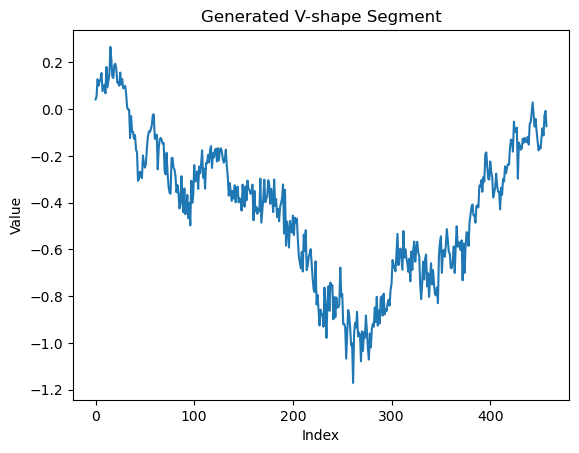

In [79]:
import matplotlib.pyplot as plt
v, _ = generate_parametric_v_segment()

plt.plot(v)
plt.title("Generated V-shape Segment")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()